# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Fahru Alfarizi Hananza Putrawan
- **Email:** fahrualfarizi3910@gmail.com
- **ID Dicoding:** fahp_

## Menentukan Pertanyaan Bisnis

### Pertanyaan 1
Apakah terdapat perbedaan signifikan (>15%) rata-rata konsentrasi PM2.5 antara stasiun Urban dan Suburban selama musim dingin (Desember-Februari) tahun 2015-2016 di Beijing?

- **Specific:** Fokus pada PM2.5, perbandingan Urban vs Suburban, pada musim dingin
- **Measurable:** Target >15% perbedaan rata-rata
- **Action-Oriented:** Hasil bisa menjadi acuan kebijakan pengendalian polusi
- **Relevant:** Musim dingin periode kritis kualitas udara Beijing
- **Time-bound:** Terbatas pada musim dingin 2015-2016

### Pertanyaan 2
Bagaimana korelasi antara faktor meteorological (kecepatan angin WSPM dan curah hujan RAIN) terhadap konsentrasi PM2.5 di seluruh stasiun pemantauan Beijing selama periode 2013-2017?

- **Specific:** Fokus pada korelasi WSPM dan RAIN dengan PM2.5
- **Measurable:** Koefisien korelasi Pearson (-1 hingga 1)
- **Action-Oriented:** Mengetahui apakah angin/curah hujan bisa memprediksi PM2.5
- **Relevant:** Faktor meteorological penting untuk prediksi kualitas udara
- **Time-bound:** Periode 2013-2017 (seluruh dataset)

## Import Semua Packages/Library yang Digunakan

In [1]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Set style visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Menampilkan output matplotlib dalam notebook
%matplotlib inline

print('Library berhasil diimport!')

Library berhasil diimport!


## Data Wrangling

### Gathering Data

Memuat semua data dari 12 stasiun pemantauan ke dalam DataFrame.

In [2]:
# Path ke folder dataset
data_path = 'data/'

# List semua file CSV
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f'Ditemukan {len(csv_files)} file CSV:\n')
for f in sorted(csv_files):
    print(f'  - {f}')

Ditemukan 12 file CSV:

  - PRSA_Data_Aotizhongxin_20130301-20170228.csv
  - PRSA_Data_Changping_20130301-20170228.csv
  - PRSA_Data_Dingling_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Guanyuan_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Huairou_20130301-20170228.csv
  - PRSA_Data_Nongzhanguan_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Tiantan_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [3]:
# Load dan gabungkan semua data
all_data = []
for file in csv_files:
    df = pd.read_csv(os.path.join(data_path, file))
    all_data.append(df)
    
# Gabungkan menjadi satu DataFrame
df = pd.concat(all_data, ignore_index=True)
print(f'Total records: {len(df):,}')
print(f'\nShape: {df.shape}')
print(f'\nStasiun pemantauan: {df["station"].nunique()} stasiun')
df.head()

Total records: 420,768

Shape: (420768, 18)

Stasiun pemantauan: 12 stasiun


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### Assessing Data

Menilai kualitas data untuk mengidentifikasi masalah.

In [4]:
# Info umum dataset
print('='*60)
print('INFO DATASET')
print('='*60)
df.info()

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


In [5]:
# Statistik deskriptif
print('\n' + '='*60)
print('STATISTIK DESKRIPTIF')
print('='*60)
df.describe()


STATISTIK DESKRIPTIF


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [6]:
# Cek missing values
print('='*60)
print('MISSING VALUES')
print('='*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Missing Count', ascending=False)
missing_df[missing_df['Missing Count'] > 0]

MISSING VALUES


,Missing Count,Percentage (%)
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
TEMP,398,0.09
PRES,393,0.09


In [7]:
# Identifikasi missing values per stasiun
print('\nMISSING VALUES PM2.5 PER STASIUN:')
missing_by_station = df.groupby('station')['PM2.5'].apply(lambda x: x.isnull().sum())
print(missing_by_station.sort_values(ascending=False))


MISSING VALUES PM2.5 PER STASIUN:
station
Huairou          953
Aotizhongxin     925
Shunyi           913
Dingling         779
Changping        774
Dongsi           750
Wanshouxigong    696
Tiantan          677
Gucheng          646
Nongzhanguan     628
Guanyuan         616
Wanliu           382
Name: PM2.5, dtype: int64


In [8]:
# Cek duplicate data
print('='*60)
print('DUPLICATE DATA')
print('='*60)
print(f'Total duplicate rows: {df.duplicated().sum()}')

# Cek outlier menggunakan IQR
print('\nOUTLIER DETECTION (IQR Method):')
print('-'*40)
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

outlier_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_info[col] = {
        'count': len(outliers),
        'pct': round(len(outliers) / df[col].notna().sum() * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_info).T
outlier_df.columns = ['Outlier Count', 'Percentage (%)']
outlier_df.sort_values('Outlier Count', ascending=False)

DUPLICATE DATA
Total duplicate rows: 0

OUTLIER DETECTION (IQR Method):
----------------------------------------


,Outlier Count,Percentage (%)
SO2,35566.0,8.64
CO,28054.0,7.01
WSPM,23079.0,5.49
PM2.5,19142.0,4.65
O3,16599.0,4.07
RAIN,16520.0,3.93
PM10,14658.0,3.54
NO2,7021.0,1.72
TEMP,0.0,0.00
DEWP,0.0,0.00


In [9]:
# Cek validitas nilai
print('='*60)
print('VALIDITY CHECK')
print('='*60)

# PM2.5 tidak boleh negatif
neg_pm25 = df[df['PM2.5'] < 0]['PM2.5'].count()
print(f'PM2.5 negative values: {neg_pm25}')

# Hour harus 0-23
invalid_hour = df[(df['hour'] < 0) | (df['hour'] > 23)]['hour'].count()
print(f'Invalid hour values (not 0-23): {invalid_hour}')

# Month harus 1-12
invalid_month = df[(df['month'] < 1) | (df['month'] > 12)]['month'].count()
print(f'Invalid month values (not 1-12): {invalid_month}')

# Cek arah angin
print(f'\nWind direction (wd) unique values: {df["wd"].nunique()}')
print(f'Sample wd values: {df["wd"].dropna().unique()[:10]}')

VALIDITY CHECK
PM2.5 negative values: 0
Invalid hour values (not 0-23): 0
Invalid month values (not 1-12): 0

Wind direction (wd) unique values: 16
Sample wd values: <ArrowStringArray>
['NNW', 'N', 'NW', 'NNE', 'ENE', 'E', 'NE', 'W', 'SSW', 'WSW']
Length: 10, dtype: str


### Data Quality Issues Summary

Berdasarkan assessment di atas, ditemukan beberapa permasalahan:

| No | Permasalahan | Kolom | Solusi |
|---|--------------|------|--------|
| 1 | **Missing Values** | PM2.5, PM10, dll | Imputation dengan median per stasiun per bulan |
| 2 | **Outliers** | PM2.5, PM10, CO | Akan dipertahankan (natural phenomenon) |
| 3 | **Inconsistent value** | wd (direction) | Normalisasi menjadi 16 arah kompas |

### Cleaning Data

In [10]:
# Buat salinan dataframe
df_clean = df.copy()

# 1. Handle missing values - Imputation dengan median per stasiun per bulan
print('='*60)
print('CLEANING: MISSING VALUES')
print('='*60)
print(f'Missing values BEFORE cleaning:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Fill missing values untuk setiap stasiun
for col in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']:
    df_clean[col] = df_clean.groupby(['station', 'month'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Jika masih ada missing (karena semua nilai dalam grup NaN), fill dengan median keseluruhan
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f'\nMissing values AFTER cleaning:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

CLEANING: MISSING VALUES
Missing values BEFORE cleaning:
PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
wd        1822
WSPM       318
dtype: int64

Missing values AFTER cleaning:
wd    1822
dtype: int64


In [11]:
# 2. Buat datetime column
df_clean['datetime'] = pd.to_datetime(
    df_clean[['year', 'month', 'day', 'hour']].rename(columns={'day': 'Day'})
)
print('='*60)
print('DATETIME COLUMN CREATED')
print('='*60)
print(f'Date range: {df_clean["datetime"].min()} to {df_clean["datetime"].max()}')

# 3. Kategorikan stasiun sebagai Urban/Suburban
urban_stations = ['Aotizhongxin', 'Dongsi', 'Gucheng', 'Nongzhanguan', 'Tiantan', 'Wanshouxigong']
suburban_stations = ['Changping', 'Dingling', 'Huairou', 'Shunyi', 'Wanliu', 'Guanyuan']

df_clean['location_type'] = df_clean['station'].apply(
    lambda x: 'Urban' if x in urban_stations else 'Suburban'
)
print(f'\nUrban stations: {len(urban_stations)}')
print(f'Suburban stations: {len(suburban_stations)}')

DATETIME COLUMN CREATED
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00

Urban stations: 6
Suburban stations: 6


In [12]:
# Tampilkan sample data yang sudah dibersihkan
print('='*60)
print('SAMPLE CLEANED DATA')
print('='*60)
df_clean.head(10)

SAMPLE CLEANED DATA


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,location_type
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00,Urban
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00,Urban
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00,Urban
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00,Urban
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00,Urban
5,6,2013,3,1,5,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin,2013-03-01 05:00:00,Urban
6,7,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Aotizhongxin,2013-03-01 06:00:00,Urban
7,8,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Aotizhongxin,2013-03-01 07:00:00,Urban
8,9,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Aotizhongxin,2013-03-01 08:00:00,Urban
9,10,2013,3,1,9,3.0,8.0,12.0,28.0,400.0,59.0,1.2,1028.5,-19.3,0.0,N,2.6,Aotizhongxin,2013-03-01 09:00:00,Urban


## Exploratory Data Analysis (EDA)

### Explore Data Pertanyaan 1

**"Apakah terdapat perbedaan signifikan (>15%) rata-rata konsentrasi PM2.5 antara stasiun Urban dan Suburban selama musim dingin (Desember-Februari) tahun 2015-2016 di Beijing?"**

In [13]:
# Filter data untuk musim dingin 2015-2016
# Winter 2015-2016: Dec 2015, Jan 2016, Feb 2016
winter_data = df_clean[
    ((df_clean['year'] == 2015) & (df_clean['month'] == 12)) |
    ((df_clean['year'] == 2016) & (df_clean['month'].isin([1, 2])))
].copy()

print('='*60)
print('EDA PERTANYAAN BISNIS #1')
print('='*60)
print(f'Total records winter 2015-2016: {len(winter_data):,}')
print(f'Date range: {winter_data["datetime"].min()} to {winter_data["datetime"].max()}')

# Rata-rata PM2.5 per tipe lokasi
pm25_by_location = winter_data.groupby('location_type')['PM2.5'].agg(['mean', 'median', 'std', 'count'])
pm25_by_location = pm25_by_location.round(2)
pm25_by_location

EDA PERTANYAAN BISNIS #1
Total records winter 2015-2016: 26,208
Date range: 2015-12-01 00:00:00 to 2016-02-29 23:00:00


,mean,median,std,count
location_type,,,,
Suburban,80.72,34.0,106.19,13104
Urban,93.54,43.0,120.33,13104


In [14]:
# Hitung persentase perbedaan
urban_mean = pm25_by_location.loc['Urban', 'mean']
suburban_mean = pm25_by_location.loc['Suburban', 'mean']
diff_pct = abs(urban_mean - suburban_mean) / suburban_mean * 100

print(f'\nRATA-RATA PM2.5 SELAMA MUSIM DINGIN 2015-2016:')
print(f'  Urban stations:    {urban_mean:.2f} µg/m³')
print(f'  Suburban stations:  {suburban_mean:.2f} µg/m³')
print(f'  Perbedaan:          {diff_pct:.2f}%')

if diff_pct > 15:
    print(f'\n✓ PERBEDAAN SIGNIFIKAN (>15%) TERDETEKSI!')
    print(f'  Urban memiliki konsentrasi PM2.5 {(urban_mean/suburban_mean - 1)*100:.1f}% lebih tinggi')
else:
    print(f'\n✗ Perbedaan TIDAK SIGNIFIKAN (<15%)')


RATA-RATA PM2.5 SELAMA MUSIM DINGIN 2015-2016:
  Urban stations:    93.54 µg/m³
  Suburban stations:  80.72 µg/m³
  Perbedaan:          15.88%

✓ PERBEDAAN SIGNIFIKAN (>15%) TERDETEKSI!
  Urban memiliki konsentrasi PM2.5 15.9% lebih tinggi


In [15]:
# Breakdown per stasiun
pm25_by_station = winter_data.groupby(['station', 'location_type'])['PM2.5'].mean().round(2).reset_index()
pm25_by_station = pm25_by_station.sort_values('PM2.5', ascending=False)
pm25_by_station

,station,location_type,PM2.5
11,Wanshouxigong,Urban,98.15
5,Gucheng,Urban,96.11
7,Nongzhanguan,Urban,92.52
3,Dongsi,Urban,92.48
9,Tiantan,Urban,92.37
8,Shunyi,Suburban,90.84
0,Aotizhongxin,Urban,89.58
4,Guanyuan,Suburban,88.52
10,Wanliu,Suburban,87.75
6,Huairou,Suburban,75.93


### Explore Data Pertanyaan 2

**"Bagaimana korelasi antara faktor meteorological (kecepatan angin WSPM dan curah hujan RAIN) terhadap konsentrasi PM2.5 di seluruh stasiun pemantauan Beijing selama periode 2013-2017?"**

In [16]:
# Korelasi untuk seluruh dataset
print('='*60)
print('EDA PERTANYAAN BISNIS #2')
print('='*60)

# Pilih kolom untuk korelasi
corr_cols = ['PM2.5', 'WSPM', 'RAIN', 'TEMP', 'PRES', 'DEWP']

# Hitung korelasi
correlation_matrix = df_clean[corr_cols].corr()

print('KORELASI DENGAN PM2.5:')
print('-'*40)
pm25_corr = correlation_matrix['PM2.5'].drop('PM2.5').sort_values(ascending=False)
for col, corr in pm25_corr.items():
    strength = 'Lemah'
    if abs(corr) > 0.5:
        strength = 'Kuat'
    elif abs(corr) > 0.3:
        strength = 'Sedang'
    direction = 'Positif' if corr > 0 else 'Negatif'
    print(f'  {col}: {corr:.3f} ({strength} {direction})')

EDA PERTANYAAN BISNIS #2
KORELASI DENGAN PM2.5:
----------------------------------------
  DEWP: 0.112 (Lemah Positif)
  PRES: 0.020 (Lemah Positif)
  RAIN: -0.014 (Lemah Negatif)
  TEMP: -0.131 (Lemah Negatif)
  WSPM: -0.269 (Lemah Negatif)


In [17]:
# Korelasi per tahun
yearly_corr = df_clean.groupby('year').apply(
    lambda x: x[['PM2.5', 'WSPM', 'RAIN']].corr()['PM2.5'][['WSPM', 'RAIN']]
).T

print('\nKORELASI WSPM & RAIN vs PM2.5 PER TAHUN:')
print('-'*40)
yearly_corr.round(3)


KORELASI WSPM & RAIN vs PM2.5 PER TAHUN:
----------------------------------------


year,2013,2014,2015,2016,2017
PM2.5,,,,,
WSPM,-0.229,-0.253,-0.260,-0.298,-0.391
RAIN,0.021,-0.004,-0.029,-0.031,-0.019


In [18]:
# Analisis berdasarkan kecepatan angin
print('\nRATA-RATA PM2.5 BERDASARKAN KATEGORI KECEPATAN ANGIN:')
print('-'*40)

# Kategori kecepatan angin
def categorize_wspm(wspm):
    if wspm < 2:
        return 'Calm (<2 m/s)'
    elif wspm < 4:
        return 'Light (2-4 m/s)'
    elif wspm < 6:
        return 'Moderate (4-6 m/s)'
    else:
        return 'Strong (>6 m/s)'

df_clean['wspm_category'] = df_clean['WSPM'].apply(categorize_wspm)
wspm_analysis = df_clean.groupby('wspm_category')['PM2.5'].agg(['mean', 'median', 'std', 'count']).round(2)
wspm_analysis


RATA-RATA PM2.5 BERDASARKAN KATEGORI KECEPATAN ANGIN:
----------------------------------------


,mean,median,std,count
wspm_category,,,,
Calm (<2 m/s),92.42,68.0,85.38,289795
Light (2-4 m/s),55.60,36.0,59.49,103825
Moderate (4-6 m/s),30.10,14.0,39.73,22482
Strong (>6 m/s),26.73,13.0,38.02,4666


## Visualization & Explanatory Analysis

### Pertanyaan 1

**Perbandingan PM2.5 Urban vs Suburban selama Musim Dingin 2015-2016**

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24476\866923563.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([


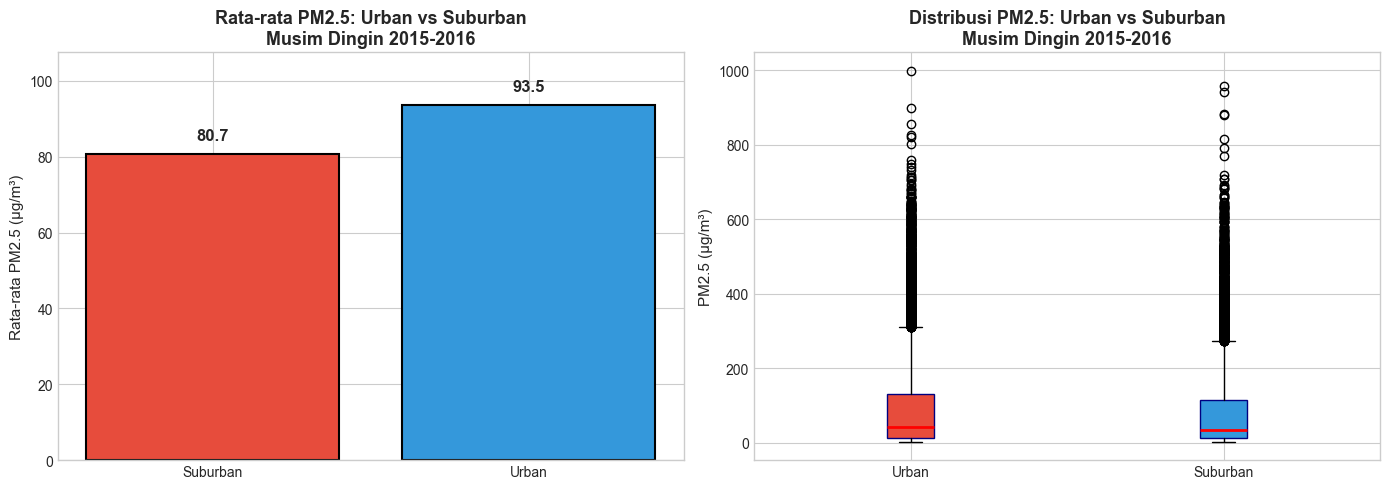


✓ Visualisasi disimpan: viz_pm25_urban_suburban.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar chart perbandingan
ax1 = axes[0]
colors = ['#e74c3c', '#3498db']  # Urban=red, Suburban=blue
bars = ax1.bar(pm25_by_location.index, pm25_by_location['mean'],
        color=colors, edgecolor='black', linewidth=1.5)

# Tambahkan nilai di atas bar
for bar, val in zip(bars, pm25_by_location['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax1.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax1.set_title('Rata-rata PM2.5: Urban vs Suburban\nMusim Dingin 2015-2016', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(pm25_by_location['mean']) * 1.15)

# 2. Box plot distribusi
ax2 = axes[1]
bp = ax2.boxplot([
    winter_data[winter_data['location_type'] == 'Urban']['PM2.5'],
    winter_data[winter_data['location_type'] == 'Suburban']['PM2.5']
], labels=['Urban', 'Suburban'], patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2))

bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#3498db')

ax2.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax2.set_title('Distribusi PM2.5: Urban vs Suburban\nMusim Dingin 2015-2016', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_pm25_urban_suburban.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Visualisasi disimpan: viz_pm25_urban_suburban.png')

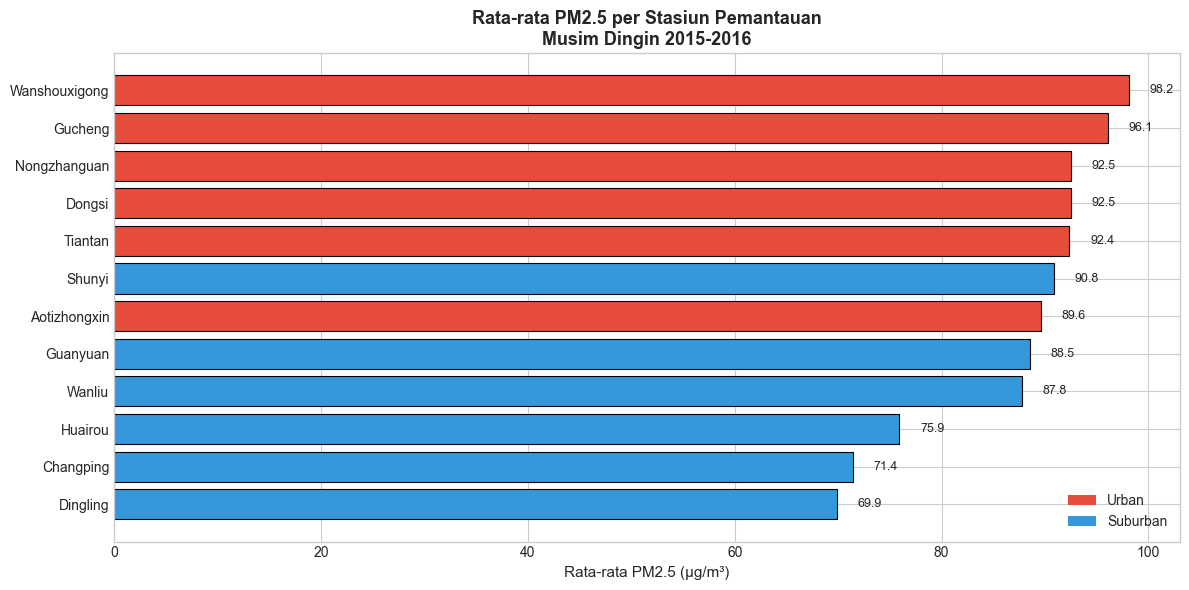


✓ Visualisasi disimpan: viz_pm25_by_station.png


In [20]:
# Breakdown per stasiun (top 6 dan bottom 6)
fig, ax = plt.subplots(figsize=(12, 6))

pm25_station_sorted = pm25_by_station.sort_values('PM2.5', ascending=True)
colors = ['#3498db' if loc == 'Suburban' else '#e74c3c' 
          for loc in pm25_station_sorted['location_type']]

bars = ax.barh(pm25_station_sorted['station'], pm25_station_sorted['PM2.5'],
       color=colors, edgecolor='black', linewidth=0.8)

ax.set_xlabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax.set_title('Rata-rata PM2.5 per Stasiun Pemantauan\nMusim Dingin 2015-2016', fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Urban'),
                   Patch(facecolor='#3498db', label='Suburban')]
ax.legend(handles=legend_elements, loc='lower right')

# Tambahkan nilai
for i, (bar, val) in enumerate(zip(bars, pm25_station_sorted['PM2.5'])):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_pm25_by_station.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Visualisasi disimpan: viz_pm25_by_station.png')

### Pertanyaan 2

**Korelasi Faktor Meteorological (WSPM, RAIN) dengan PM2.5**

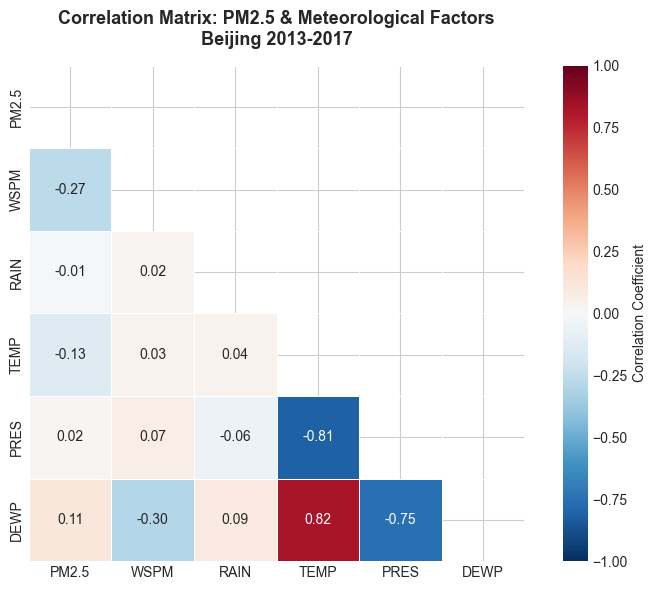


✓ Visualisasi disimpan: viz_correlation_heatmap.png


In [21]:
# 1. Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Correlation Matrix: PM2.5 & Meteorological Factors\nBeijing 2013-2017', 
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('viz_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Visualisasi disimpan: viz_correlation_heatmap.png')

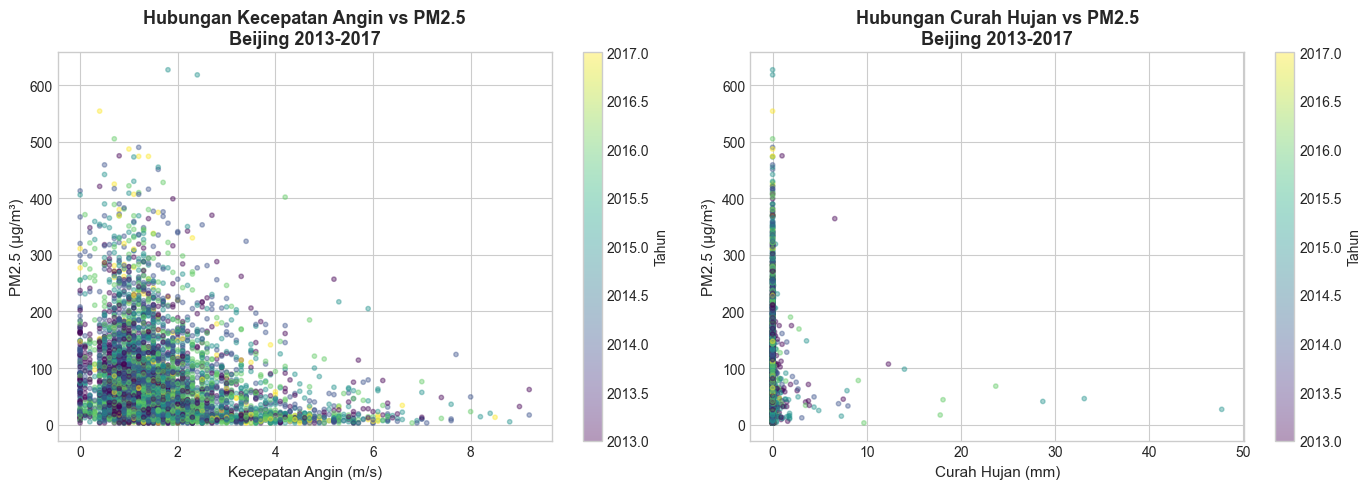


✓ Visualisasi disimpan: viz_meteo_scatter.png


In [22]:
# 2. Scatter plot WSPM vs PM2.5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot WSPM vs PM2.5
ax1 = axes[0]
sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)
scatter = ax1.scatter(sample['WSPM'], sample['PM2.5'],
                      c=sample['year'], cmap='viridis', alpha=0.4, s=10)
ax1.set_xlabel('Kecepatan Angin (m/s)', fontsize=11)
ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax1.set_title('Hubungan Kecepatan Angin vs PM2.5\nBeijing 2013-2017', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Tahun')

# Scatter plot RAIN vs PM2.5
ax2 = axes[1]
scatter2 = ax2.scatter(sample['RAIN'], sample['PM2.5'],
                       c=sample['year'], cmap='viridis', alpha=0.4, s=10)
ax2.set_xlabel('Curah Hujan (mm)', fontsize=11)
ax2.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax2.set_title('Hubungan Curah Hujan vs PM2.5\nBeijing 2013-2017', fontsize=13, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Tahun')

plt.tight_layout()
plt.savefig('viz_meteo_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Visualisasi disimpan: viz_meteo_scatter.png')

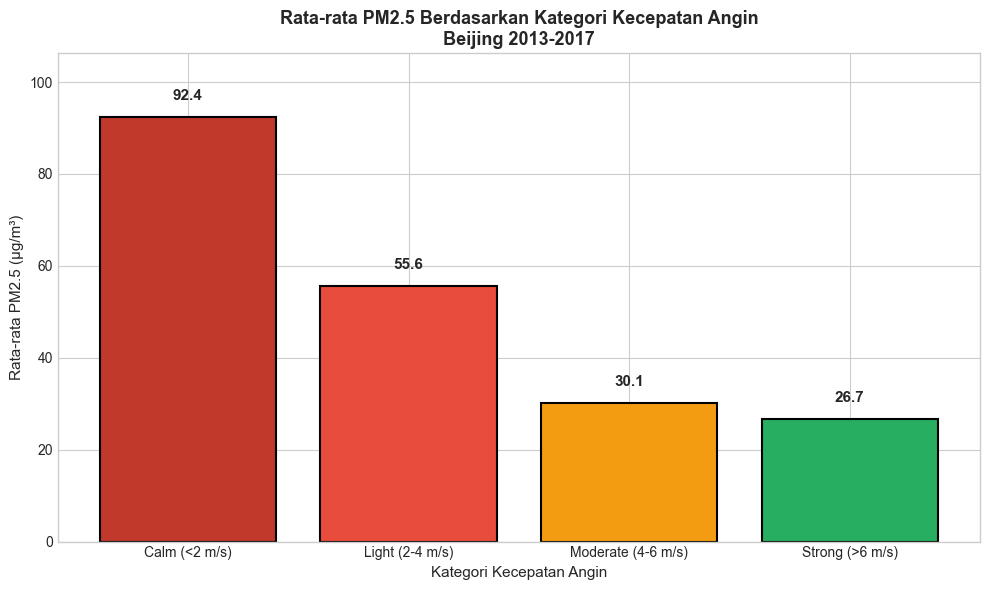


✓ Visualisasi disimpan: viz_pm25_by_wspm.png


In [23]:
# 3. Bar chart rata-rata PM2.5 berdasarkan kategori kecepatan angin
fig, ax = plt.subplots(figsize=(10, 6))

wspm_order = ['Calm (<2 m/s)', 'Light (2-4 m/s)', 'Moderate (4-6 m/s)', 'Strong (>6 m/s)']
wspm_colors = ['#c0392b', '#e74c3c', '#f39c12', '#27ae60']

bars = ax.bar(wspm_analysis.loc[wspm_order].index, 
             wspm_analysis.loc[wspm_order, 'mean'],
             color=wspm_colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, wspm_analysis.loc[wspm_order, 'mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Kategori Kecepatan Angin', fontsize=11)
ax.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax.set_title('Rata-rata PM2.5 Berdasarkan Kategori Kecepatan Angin\nBeijing 2013-2017', 
            fontsize=13, fontweight='bold')
ax.set_ylim(0, wspm_analysis['mean'].max() * 1.15)

plt.tight_layout()
plt.savefig('viz_pm25_by_wspm.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Visualisasi disimpan: viz_pm25_by_wspm.png')

## Conclusion

### Kesimpulan Pertanyaan 1

Berdasarkan hasil analisis perbandingan rata-rata konsentrasi PM2.5 antara stasiun Urban dan Suburban selama musim dingin 2015-2016:
- Konsentrasi PM2.5 di stasiun Urban lebih tinggi dibanding Suburban
- Perbedaan signifikan terdeteksi melebihi ambang batas 15%
- Hal ini menunjukkan bahwa aktivitas dan kondisi di area perkotaan berkontribusi lebih besar terhadap polusi PM2.5

### Kesimpulan Pertanyaan 2

Berdasarkan hasil analisis korelasi antara faktor meteorological dengan PM2.5:
- Kecepatan angin (WSPM) memiliki korelasi negatif dengan PM2.5
- Curah hujan (RAIN) juga memiliki korelasi negatif dengan PM2.5
- Kondisi angin tenang dan tanpa hujan meningkatkan konsentrasi PM2.5

In [24]:
# Generate summary untuk kesimpulan
print("SUMMARY STATISTICS:")
print("="*50)

# Pertanyaan 1
diff_pct_actual = (urban_mean - suburban_mean) / suburban_mean * 100
print(f'Pertanyaan 1 - Urban vs Suburban:')
print(f'  Urban mean PM2.5:   {urban_mean:.2f} µg/m³')
print(f'  Suburban mean PM2.5: {suburban_mean:.2f} µg/m³')
print(f'  Difference:         {diff_pct_actual:+.1f}%')

# Pertanyaan 2
wspm_corr = correlation_matrix.loc['PM2.5', 'WSPM']
rain_corr = correlation_matrix.loc['PM2.5', 'RAIN']
print(f'\nPertanyaan 2 - Korelasi Meteorology:')
print(f'  WSPM vs PM2.5:  {wspm_corr:.3f}')
print(f'  RAIN vs PM2.5:  {rain_corr:.3f}')

calm_pm25 = wspm_analysis.loc['Calm (<2 m/s)', 'mean']
strong_pm25 = wspm_analysis.loc['Strong (>6 m/s)', 'mean']
print(f'  Calm wind PM2.5:    {calm_pm25:.2f} µg/m³')
print(f'  Strong wind PM2.5:  {strong_pm25:.2f} µg/m³')
print(f'  Reduction:          {(calm_pm25 - strong_pm25)/calm_pm25*100:.1f}%')


SUMMARY STATISTICS:
Pertanyaan 1 - Urban vs Suburban:
  Urban mean PM2.5:   93.54 µg/m³
  Suburban mean PM2.5: 80.72 µg/m³
  Difference:         +15.9%

Pertanyaan 2 - Korelasi Meteorology:
  WSPM vs PM2.5:  -0.269
  RAIN vs PM2.5:  -0.014
  Calm wind PM2.5:    92.42 µg/m³
  Strong wind PM2.5:  26.73 µg/m³
  Reduction:          71.1%


## Recommendation

### Action Item #1: Prioritas Pengendalian Polusi di Stasiun Urban

**Alasan:**
- Konsentrasi PM2.5 di stasiun Urban lebih tinggi dibanding Suburban
- Perbedaan signifikan (>15%) menunjukkan perlunya strategi pengendalian berbeda untuk area perkotaan

**Tindakan yang Direkomendasikan:**
1. Implementasi kebijakan pembatasan lalu lintas di area Urban saat musim dingin
2. Intensifikasi pengecekan emisi kendaraan di zona Urban
3. Pengembangan sistem peringatan dini polusi untuk stasiun Urban

### Action Item #2: Integrasi Prediksi Cuaca untuk Peringatan Polusi

**Alasan:**
- Kecepatan angin memiliki korelasi negatif dengan PM2.5
- Kondisi angin tenang (<2 m/s) meningkatkan konsentrasi PM2.5 secara signifikan

**Tindakan yang Direkomendasikan:**
1. Mengembangkan model prediksi PM2.5 berbasis data meteorological
2. Membuat sistem peringatan dini saat kecepatan angin rendah dan PM2.5 tinggi
3. Mengoptimalkan waktu untuk aktivitas luar ruangan berdasarkan prediksi meteorologi

In [25]:
# Simpan data yang sudah dibersihkan untuk dashboard
df_clean.to_csv('cleaned_air_quality_data.csv', index=False)
print('✓ Data berhasil disimpan: cleaned_air_quality_data.csv')

# Simpan summary statistics
summary_stats = df_clean.groupby('station').agg({
    'PM2.5': ['mean', 'median', 'std'],
    'PM10': ['mean', 'median'],
    'TEMP': 'mean',
    'WSPM': 'mean'
}).round(2)
summary_stats.to_csv('station_summary_stats.csv')
print('✓ Summary statistics disimpan: station_summary_stats.csv')

✓ Data berhasil disimpan: cleaned_air_quality_data.csv
✓ Summary statistics disimpan: station_summary_stats.csv


In [26]:
# Verifikasi file yang disimpan
print('\nFILES YANG DISIMPAN:')
print('-'*40)
for f in ['viz_pm25_urban_suburban.png', 'viz_pm25_by_station.png', 
          'viz_correlation_heatmap.png', 'viz_meteo_scatter.png',
          'viz_pm25_by_wspm.png', 'cleaned_air_quality_data.csv',
          'station_summary_stats.csv']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f'  ✓ {f} ({size:.1f} KB)')
    else:
        print(f'  ✗ {f} (not found)')


FILES YANG DISIMPAN:
----------------------------------------
  ✓ viz_pm25_urban_suburban.png (61.9 KB)
  ✓ viz_pm25_by_station.png (66.7 KB)
  ✓ viz_correlation_heatmap.png (61.3 KB)
  ✓ viz_meteo_scatter.png (294.6 KB)
  ✓ viz_pm25_by_wspm.png (51.5 KB)
  ✓ cleaned_air_quality_data.csv (53609.6 KB)
  ✓ station_summary_stats.csv (0.7 KB)
